### **Import**

In [32]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import matplotlib.pyplot as plt

### **Random seed**

In [33]:
import os
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

### **Load data + Normalize**

In [34]:
from torch_geometric.utils import to_undirected

data = torch.load('../data/processed/pyg_data.pt')
data.edge_index = to_undirected(data.edge_index)

train_features = data.x[data.train_mask]
train_mean = train_features.mean(dim=0)
train_std = train_features.std(dim=0)

data.x = (data.x - train_mean) / (train_std + 1e-8)
print(data)
device = torch.device('cpu')
data = data.to(device)

Data(x=[203769, 165], edge_index=[2, 468710], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])


### **Define the model**

2-layer Graph Convolutional Network (GCN) structure:

In [35]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

model = GCN(
    in_channels=data.x.shape[1],
    hidden_channels=64,
    out_channels=2,           
    dropout=0.5,
).to(device)

print(model)
print(f"Number of parameter: {sum(p.numel() for p in model.parameters()):,}")

GCN(
  (conv1): GCNConv(165, 64)
  (conv2): GCNConv(64, 2)
)
Number of parameter: 10,754


### **Define optimizer and loss**

In [36]:
import math

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

n_licit   = (data.y[data.train_mask] == 0).sum().item()
n_illicit = (data.y[data.train_mask] == 1).sum().item()
weight = torch.tensor([1.0,  math.sqrt(n_licit / n_illicit)], dtype=torch.float).to(device)
criterion = torch.nn.CrossEntropyLoss(weight=weight)

print(f"Class weights: licit={weight[0]:.2f}, illicit={weight[1]:.2f}")

Class weights: licit=1.00, illicit=2.86


### **Training loop**

In [37]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    average_precision_score, confusion_matrix, classification_report
)

def train_one_epoch():
    model.train()                             
    optimizer.zero_grad()                        
    out = model(data.x, data.edge_index)             
    loss = criterion(out[data.train_mask], data.y[data.train_mask])  
    loss.backward()                                 
    optimizer.step()                                
    return loss.item()

@torch.no_grad()
def evaluate(mask):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out[mask].argmax(dim=1)
    probs = F.softmax(out[mask], dim=1)[:, 1]  # probability of illicit
    y_true = data.y[mask].cpu().numpy()
    y_pred = pred.cpu().numpy()
    y_prob = probs.cpu().numpy()
    loss = criterion(out[mask], data.y[mask]).item()
    
    acc = accuracy_score(y_true, y_pred)
    precision_ill = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall_ill = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1_ill = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    auc_pr = average_precision_score(y_true, y_prob)
    return {
        'loss': loss, 'accuracy': acc,
        'precision_ill': precision_ill, 'recall_ill': recall_ill,
        'f1_ill': f1_ill, 'f1_macro': f1_macro, 'auc_pr': auc_pr,
    }

### **Train loop**

In [38]:
# ... (Giữ nguyên các hàm train_one_epoch và evaluate)

NUM_EPOCHS = 200
PATIENCE = 20  

history = {'train_loss': [], 'val_loss': [], 'val_recall': []}
monitor_metric = 'f1_ill'
best_val_score = 0.0  # Đổi tên cho đồng nhất
epochs_no_improve = 0
best_epoch = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch()
    
    val_metrics = evaluate(data.val_mask)
    
    val_loss = val_metrics['loss']
    val_recall = val_metrics['recall_ill']
    val_f1 = val_metrics['f1_ill']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_recall'].append(val_recall)

    if val_metrics[monitor_metric] > best_val_score:
        best_val_score = val_metrics[monitor_metric]
        best_epoch = epoch
        torch.save(model.state_dict(), '../saved_models/gcn_best.pt')
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    print(f"Epoch {epoch:03d}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Val F1-Ill={val_f1:.4f}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} (Best epoch: {best_epoch})")
        break

print(f"\nBest Val {monitor_metric}: {best_val_score:.4f} at epoch {best_epoch}")

Epoch 001: Train Loss=0.8818, Val Loss=0.6102, Val F1-Ill=0.3818
Epoch 002: Train Loss=0.4893, Val Loss=0.5253, Val F1-Ill=0.5125
Epoch 003: Train Loss=0.3745, Val Loss=0.5036, Val F1-Ill=0.5269
Epoch 004: Train Loss=0.3314, Val Loss=0.5133, Val F1-Ill=0.5131
Epoch 005: Train Loss=0.3024, Val Loss=0.5235, Val F1-Ill=0.5117
Epoch 006: Train Loss=0.2961, Val Loss=0.5244, Val F1-Ill=0.5303
Epoch 007: Train Loss=0.2737, Val Loss=0.5248, Val F1-Ill=0.5542
Epoch 008: Train Loss=0.2679, Val Loss=0.5265, Val F1-Ill=0.5664
Epoch 009: Train Loss=0.2642, Val Loss=0.5203, Val F1-Ill=0.5697
Epoch 010: Train Loss=0.2522, Val Loss=0.5075, Val F1-Ill=0.5799
Epoch 011: Train Loss=0.2442, Val Loss=0.4958, Val F1-Ill=0.5848
Epoch 012: Train Loss=0.2378, Val Loss=0.4884, Val F1-Ill=0.5865
Epoch 013: Train Loss=0.2336, Val Loss=0.4833, Val F1-Ill=0.5929
Epoch 014: Train Loss=0.2403, Val Loss=0.4764, Val F1-Ill=0.6099
Epoch 015: Train Loss=0.2362, Val Loss=0.4670, Val F1-Ill=0.6270
Epoch 016: Train Loss=0.2

### **Training curves**

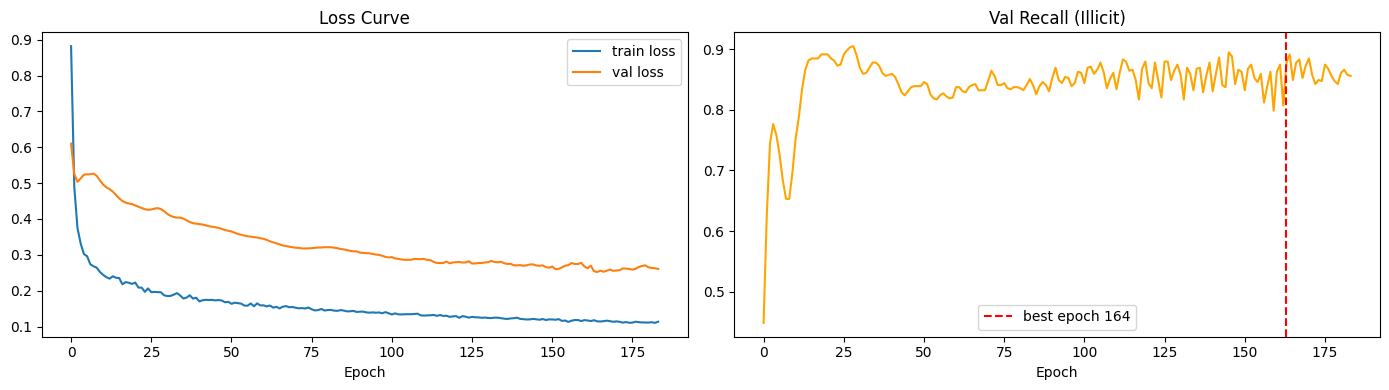

In [39]:
import os 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history['train_loss'], label='train loss')
ax1.plot(history['val_loss'], label='val loss')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history['val_recall'], color='orange')
ax2.axvline(x=best_epoch-1, color='red', linestyle='--', label=f'best epoch {best_epoch}')
ax2.set_title('Val Recall (Illicit)')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
save_dir = '../reports/figures'
file_path = f'{save_dir}/gcn_training_curve.png'
os.makedirs(save_dir, exist_ok=True)

plt.savefig(file_path, dpi=150)
plt.show()

### **Evaluation on test set**

In [40]:
model.load_state_dict(torch.load('../saved_models/gcn_best.pt'))

test_metrics = evaluate(data.test_mask) 

print(f"Test Accuracy:          {test_metrics['accuracy']:.4f}")
print(f"Test Precision (Ill):   {test_metrics['precision_ill']:.4f}")
print(f"Test Recall (Ill):      {test_metrics['recall_ill']:.4f}")
print(f"Test F1-Illicit:        {test_metrics['f1_ill']:.4f}")
print(f"Test F1-macro:          {test_metrics['f1_macro']:.4f}")
print(f"Test AUC-PR:            {test_metrics['auc_pr']:.4f}")


Test Accuracy:          0.9403
Test Precision (Ill):   0.5386
Test Recall (Ill):      0.5669
Test F1-Illicit:        0.5524
Test F1-macro:          0.7602
Test AUC-PR:            0.5220


### **Confusion Matrix**

In [41]:
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)
    pred = out[data.test_mask].argmax(dim=1).cpu()
    true = data.y[data.test_mask].cpu()

print(confusion_matrix(true, pred))
print(classification_report(true, pred, target_names=['licit', 'illicit']))

from sklearn.metrics import f1_score
f1 = f1_score(true, pred, average='macro')
print(f"F1-macro: {f1:.4f}")

[[15061   526]
 [  469   614]]
              precision    recall  f1-score   support

       licit       0.97      0.97      0.97     15587
     illicit       0.54      0.57      0.55      1083

    accuracy                           0.94     16670
   macro avg       0.75      0.77      0.76     16670
weighted avg       0.94      0.94      0.94     16670

F1-macro: 0.7602
